In [33]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# IMPORTANT FOR REPRODUCIBILITY
RANDOM_STATE = 0
TEST_SIZE = 0.20
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [34]:
# READ DATA

df = pd.read_csv("filtered_data.csv")

# drop duplicate rows from dataset to prevent data leakage
df = df.drop_duplicates()

print(f"Shape: {df.shape}\n")
print(f"Class Counts: {df['diseases'].value_counts()}\n")
print(f"NaNs: {df.isna().sum().sum()}\n")
# show symptom values are binary 0 or 1 only
print(f"Unique Symptom Values: {np.unique(df.iloc[:, 1:].values)}")

Shape: (2473, 39)

Class Counts: diseases
panic disorder    810
heart attack      810
flu               521
migraine          203
head injury       129
Name: count, dtype: int64

NaNs: 0

Unique Symptom Values: [0 1]


In [35]:
# LABEL ENCODING AND TRAIN TEST SPLIT

X = df.drop(columns=["diseases"]).values

# encode true labels as integers to pair with sparse categorical cross-entropy loss
raw_labels = df["diseases"]
label_to_int = {
    "flu": 0,
    "head injury": 1,
    "heart attack": 2,
    "migraine": 3,
    "panic disorder": 4
}
int_to_label = {i: label for label, i in label_to_int.items()}
y = raw_labels.map(label_to_int).values

num_features = X.shape[1]
num_classes = len(label_to_int)
print(f"Label Encoding: {label_to_int}")
print(f"Features: {num_features}")
print(f"Classes: {num_classes}")

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

# save train/test split
np.savez_compressed("train_test_split.npz",
                    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
                    class_names=np.array([int_to_label[i] for i in range(num_classes)]))

print("Saved train_test_split.npz")


Label Encoding: {'flu': 0, 'head injury': 1, 'heart attack': 2, 'migraine': 3, 'panic disorder': 4}
Features: 38
Classes: 5
Train: (1978, 38)
Test: (495, 38)
Saved train_test_split.npz


In [36]:
# CLASS WEIGHTS
# class weighting was not used in the final model
# since it wasn't necessary to aid performance
weights = compute_class_weight(class_weight="balanced",
                               classes=np.arange(num_classes),
                               y=y_train)
class_weight = {i: w for i, w in enumerate(weights)}

print("Class weights:", {int_to_label[i]: round(w, 3) for i, w in class_weight.items()})

Class weights: {'flu': np.float64(0.949), 'head injury': np.float64(3.841), 'heart attack': np.float64(0.61), 'migraine': np.float64(2.442), 'panic disorder': np.float64(0.61)}


In [37]:
# MODEL INITIALIZATION
model = keras.Sequential([
    keras.Input(shape=(num_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,821 (11.02 KB)

 Trainable params: 2,821 (11.02 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# MODEL TRAINING
# stop training once validation loss has stopped meaningfully improving for 10 epochs
# then restore model to weights that achieved lowest loss
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=64,
    # implemented class weighting to account for imbalanced dataset
    # but the model doesn't seem to need it
    # class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/200
25/25 - 1s - 45ms/step - accuracy: 0.3742 - loss: 1.4611 - val_accuracy: 0.7929 - val_loss: 1.1805
Epoch 2/200
25/25 - 0s - 8ms/step - accuracy: 0.8546 - loss: 0.9619 - val_accuracy: 0.9394 - val_loss: 0.7573
Epoch 3/200
25/25 - 0s - 13ms/step - accuracy: 0.9393 - loss: 0.5867 - val_accuracy: 0.9747 - val_loss: 0.4597
Epoch 4/200
25/25 - 0s - 6ms/step - accuracy: 0.9728 - loss: 0.3531 - val_accuracy: 0.9798 - val_loss: 0.2887
Epoch 5/200
25/25 - 0s - 4ms/step - accuracy: 0.9874 - loss: 0.2341 - val_accuracy: 0.9874 - val_loss: 0.1931
Epoch 6/200
25/25 - 0s - 5ms/step - accuracy: 0.9930 - loss: 0.1626 - val_accuracy: 0.9874 - val_loss: 0.1377
Epoch 7/200
25/25 - 0s - 5ms/step - accuracy: 0.9949 - loss: 0.1169 - val_accuracy: 0.9899 - val_loss: 0.1041
Epoch 8/200
25/25 - 0s - 5ms/step - accuracy: 0.9962 - loss: 0.0874 - val_accuracy: 0.9899 - val_loss: 0.0825
Epoch 9/200
25/25 - 0s - 5ms/step - accuracy: 0.9962 - loss: 0.0736 - val_accuracy: 0.9924 - val_loss: 0.0674
Epoch 10

In [39]:
# MODEL EVALUATION
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

labels = [int_to_label[i] for i in range(num_classes)]

# metrics
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"MACRO F1: {macro_f1}\n")

acc = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc}")
print(f"Weighted F1: {weighted_f1}")
print(f"Precision (macro) : {macro_precision}")
print(f"Recall (macro) : {macro_recall}")
print("\n")
print(classification_report(y_test, y_pred, target_names=labels))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MACRO F1: 0.9956809116809117

Accuracy: 0.9959595959595959
Weighted F1: 0.9959502335798632
Precision (macro) : 0.9975384382337348
Recall (macro) : 0.9938873833182775


                precision    recall  f1-score   support

           flu       1.00      1.00      1.00       104
   head injury       1.00      1.00      1.00        26
  heart attack       0.99      0.99      0.99       162
      migraine       1.00      0.98      0.99        41
panic disorder       0.99      1.00      1.00       162

      accuracy                           1.00       495
     macro avg       1.00      0.99      1.00       495
  weighted avg       1.00      1.00      1.00       495



In [40]:
# 5-FOLD CROSS VALIDATION
from sklearn.model_selection import StratifiedKFold

X_cv = df.drop(columns=["diseases"]).values
y_cv = df["diseases"].map(label_to_int).values

# validation history
fold_acc, fold_f1_macro, fold_f1_weighted = [], [], []

# 5-fold cv
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (train_index, test_index) in enumerate(skf.split(X_cv, y_cv), start=1):
  X_cv_train, X_cv_test = X_cv[train_index], X_cv[test_index]
  y_cv_train, y_cv_test = y_cv[train_index], y_cv[test_index]

  # train model on current fold
  fold_model = keras.Sequential([
      keras.Input(shape=(X_cv.shape[1],)),
      layers.Dense(64, activation="relu"),
      layers.Dropout(0.3),
      layers.Dense(num_classes, activation="softmax")
  ])
  fold_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
  fold_model.fit(X_cv_train, y_cv_train,
              validation_split=0.20,
              epochs=200,
              batch_size=64,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",
                                                        patience=10,
                                                        restore_best_weights=True)],
              verbose=0)

  # evaluate model with current fold
  fold_predictions = fold_model.predict(X_cv_test, verbose=0).argmax(axis=1)

  current_fold_acc = accuracy_score(y_cv_test, fold_predictions)
  current_fold_f1_macro = f1_score(y_cv_test, fold_predictions, average="macro")
  current_fold_f1_weighted = f1_score(y_cv_test, fold_predictions, average="weighted")
  fold_acc.append(current_fold_acc)

  fold_f1_macro.append(current_fold_f1_macro)
  fold_f1_weighted.append(current_fold_f1_weighted)

  print(f"Fold {fold}:")
  print(f"--accuracy={current_fold_acc}")
  print(f"--macro f1={current_fold_f1_macro}")
  print(f"--weighted f1={current_fold_f1_weighted}")

# final averaged metrics
print(f"Mean accuracy: {np.mean(fold_acc)} +- {np.std(fold_acc)}")
print(f"Mean macro F1: {np.mean(fold_f1_macro)} +- {np.std(fold_f1_macro)}")
print(f"Mean weighted F1: {np.mean(fold_f1_weighted)} +- {np.std(fold_f1_weighted)}")


Fold 1:
--accuracy=0.9939393939393939
--macro f1=0.9900143472022955
--weighted f1=0.9940019999130473
Fold 2:
--accuracy=0.98989898989899
--macro f1=0.9835796387520525
--weighted f1=0.9900648521338177
Fold 3:
--accuracy=0.9919191919191919
--macro f1=0.9890018185028022
--weighted f1=0.991945543204546
Fold 4:
--accuracy=0.9878542510121457
--macro f1=0.9820746060814385
--weighted f1=0.988027273163506
Fold 5:
--accuracy=0.9858299595141701
--macro f1=0.9769428718476583
--weighted f1=0.9861532766156653
Mean accuracy: 0.9898883572567783 +- 0.0028685704151963478
Mean macro F1: 0.9843226564772494 +- 0.00478240374021608
Mean weighted F1: 0.9900385890061164 +- 0.0027744128702877524


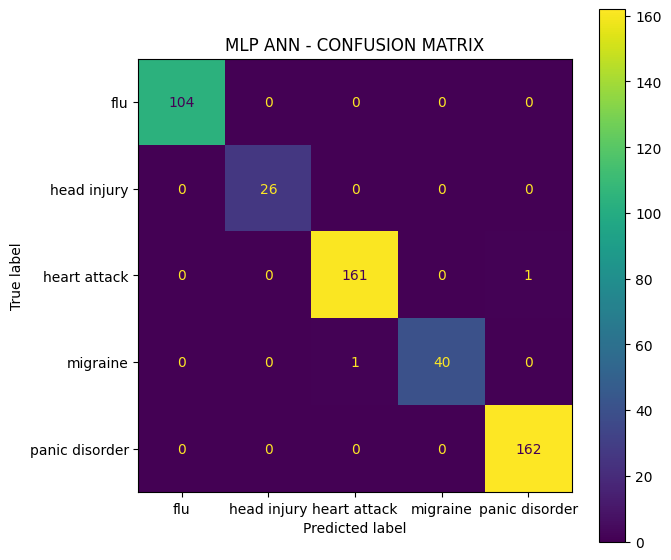

In [41]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
cm_display.plot(ax=ax)
ax.set_title("MLP ANN - CONFUSION MATRIX")
plt.tight_layout()
plt.savefig("mlp_ann_confusion_matrix.png")
plt.show()